In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()


False

In [2]:
 # Define the state structure
class BMIState(TypedDict):
    weight: float  # in kilograms
    height: float  # in meters
    bmi: float     # Body Mass Index
    category: str  # BMI category   

def calculate_bmi(state: BMIState) -> BMIState:
    """Calculate BMI given weight and height."""
    state['bmi'] = state['weight'] / (state['height'] ** 2)
    return state

In [3]:
def label_bmi(state: BMIState) -> BMIState:
    """Label BMI category."""
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state

In [4]:
# Define the state graph
graph = StateGraph(BMIState)

# add node to your graph
graph.add_node("calcualteBmi", calculate_bmi)
graph.add_node("labelBmi", label_bmi)

# add edges to your grpah
graph.add_edge(START, "calcualteBmi")
graph.add_edge("calcualteBmi", "labelBmi")
graph.add_edge("labelBmi", END)

# compile th graph
workflow = graph.compile()

# execute the graph
state  = workflow.invoke({"weight": 70, "height": 1.75})

state

{'weight': 70,
 'height': 1.75,
 'bmi': 22.857142857142858,
 'category': 'Normal weight'}

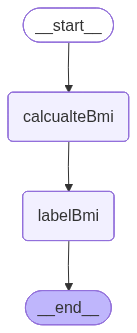

In [5]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())